In [111]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from ISLP import load_data, confusion_table
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LassoCV, RidgeCV, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from ISLP.models import ModelSpec
from ISLP.bart import BART

# 3. # 
Consider the Gini index, classification error, and entropy in a simple
classification setting with two classes. Create a single plot that displays each of these quantities as a function of ˆpm1. The x-axis should
display ˆpm1, ranging from 0 to 1, and the y-axis should display the
value of the Gini index, classification error, and entropy.
Hint: In a setting with two classes, ˆpm1 =1− ˆpm2. You could make
this plot by hand, but it will be much easier to make in R.

In [3]:
pm1 = np.linspace(0.001,0.999)
pm2 = 1-pm1

Gini:
$$ G = \sum_{k=1}^{K} \hat{p}_{mk} (1 - \hat{p}_{mk}) $$

Entropy:
$$ D = - \sum_{k=1}^{K} \hat{p}_{mk} \log(\hat{p}_{mk}) $$

Taxa de Erro de Classificação:
$$ E = 1 - \max_k(\hat{p}_{mk}) $$

In [4]:
g = pm1*(1 - pm1) + pm2*(1 - pm2) 

In [5]:
d = - ((pm1*np.log(pm1)) + (pm2*np.log(pm2)))

In [6]:
d_log2 = - ((pm1*np.log2(pm1)) + (pm2*np.log2(pm2)))

In [7]:
e = 1 - np.maximum(pm1, pm2)

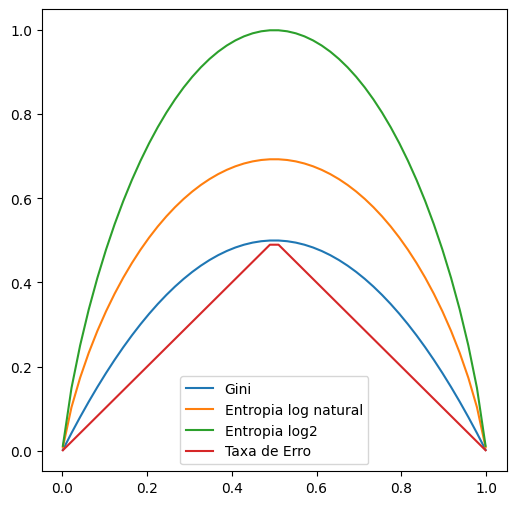

In [8]:
ax = subplots(figsize=(6,6))[1]
ax.plot(pm1, g, label='Gini')
ax.plot(pm1, d, label='Entropia log natural')
ax.plot(pm1, d_log2, label='Entropia log2')
ax.plot(pm1, e, label='Taxa de Erro')
ax.legend();

# 7. #
In Section 8.3.3, we applied random forests to the Boston data using
max_features = 6 and using n_estimators = 100 and n_estimators =
500. Create a plot displaying the test error resulting from random
forests on this data set for a more comprehensive range of values
for max_features and n_estimators. You can model your plot after
Figure 8.10. Describe the results obtained.

In [ ]:
Boston = load_data('Boston')
(X_treino,
X_teste,
y_treino,
y_teste) = train_test_split(Boston.drop(columns=['medv']), Boston['medv'], test_size=0.3, random_state=0)
rf = RandomForestRegressor(max_features=6, n_estimators=100, random_state=0).fit(X_treino,y_treino)
np.mean((y_teste - rf.predict(X_teste))**2)

np.float64(20.04276446710527)

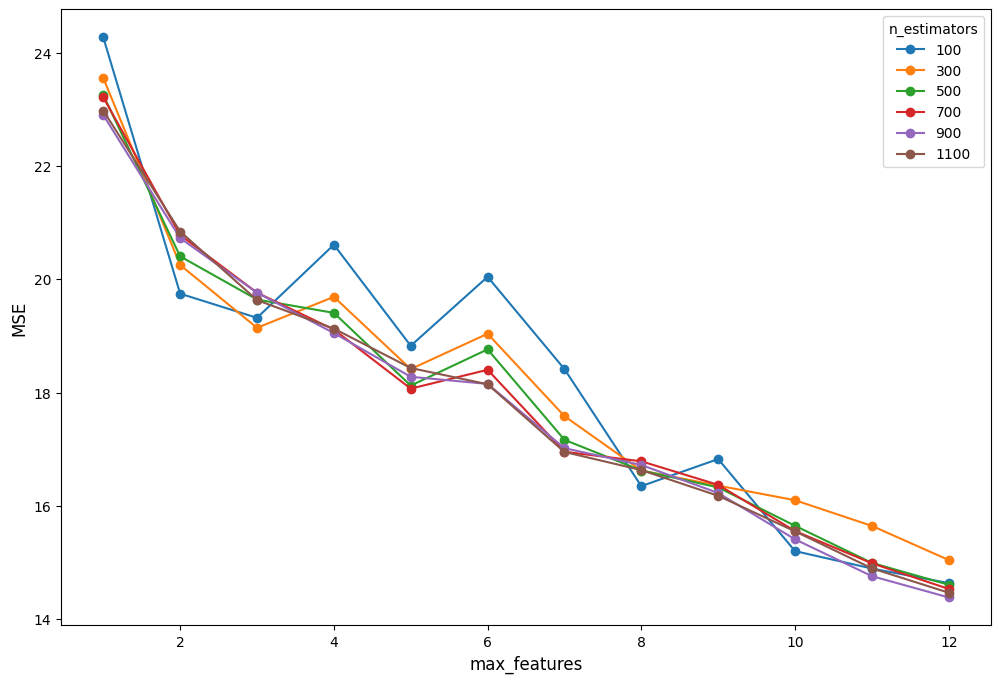

In [10]:
max_features = np.arange(1, 13)
n_estimators = np.arange(100, 1101, 200)

ax = subplots(figsize=(12,8))[1]

for j in n_estimators:
    mse_ = []
    for i in max_features:
        mse = np.mean((y_teste - RandomForestRegressor(max_features=i, n_estimators=j, random_state=0).fit(X_treino,y_treino).predict(X_teste))**2)
        mse_.append(mse)
    ax.plot(max_features, mse_, marker='o', linestyle='-', label=j)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_xlabel('max_features', fontsize=12)

ax.legend(title='n_estimators')

# 8. # 
In the lab, a classification tree was applied to the Carseats data set af
ter converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

(a) Split the data set into a training set and a test set.

In [133]:
Carseats = load_data('Carseats')
modelspec = ModelSpec(Carseats.columns.drop('Sales'), intercept=False)
(X_treino,
 X_teste,
 y_treino,
 y_teste) = train_test_split(modelspec.fit_transform(Carseats), Carseats.Sales, train_size=.20, random_state=42)
nomes_preditores = X_treino.columns
Carseats.info(), nomes_preditores

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Sales        400 non-null    float64 
 1   CompPrice    400 non-null    int64   
 2   Income       400 non-null    int64   
 3   Advertising  400 non-null    int64   
 4   Population   400 non-null    int64   
 5   Price        400 non-null    int64   
 6   ShelveLoc    400 non-null    category
 7   Age          400 non-null    int64   
 8   Education    400 non-null    int64   
 9   Urban        400 non-null    category
 10  US           400 non-null    category
dtypes: category(3), float64(1), int64(7)
memory usage: 26.7 KB


(None,
 Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price',
        'ShelveLoc[Good]', 'ShelveLoc[Medium]', 'Age', 'Education',
        'Urban[Yes]', 'US[Yes]'],
       dtype='object'))

(b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

MSE Teste: 7.136780625


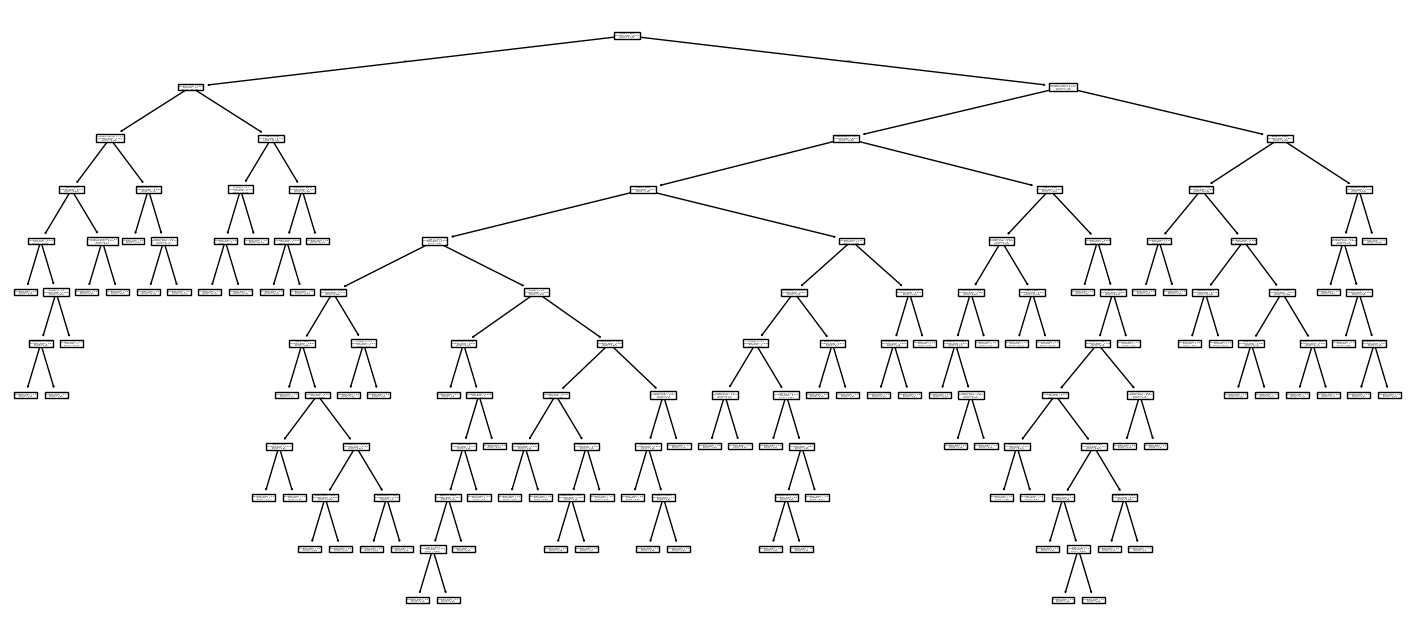

In [134]:
dtr = DecisionTreeRegressor()
dtr.fit(X_treino, y_treino)

print(f'MSE Teste: {np.mean((y_teste - dtr.predict(X_teste))**2)}')
ax = subplots(figsize=(18, 8))[1]
plot_tree(dtr, 
          feature_names=nomes_preditores, 
          ax=ax);

In [135]:
print(export_text(dtr, feature_names=nomes_preditores, show_weights=True, max_depth=4))

|--- Price <= 95.00
|   |--- CompPrice <= 117.50
|   |   |--- ShelveLoc[Good] <= 0.50
|   |   |   |--- Age <= 67.00
|   |   |   |   |--- CompPrice <= 96.00
|   |   |   |   |   |--- value: [8.41]
|   |   |   |   |--- CompPrice >  96.00
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Age >  67.00
|   |   |   |   |--- ShelveLoc[Medium] <= 0.50
|   |   |   |   |   |--- value: [8.01]
|   |   |   |   |--- ShelveLoc[Medium] >  0.50
|   |   |   |   |   |--- value: [8.07]
|   |   |--- ShelveLoc[Good] >  0.50
|   |   |   |--- Advertising <= 13.00
|   |   |   |   |--- value: [10.96]
|   |   |   |--- Advertising >  13.00
|   |   |   |   |--- Education <= 14.00
|   |   |   |   |   |--- value: [11.22]
|   |   |   |   |--- Education >  14.00
|   |   |   |   |   |--- value: [11.48]
|   |--- CompPrice >  117.50
|   |   |--- Age <= 47.00
|   |   |   |--- US[Yes] <= 0.50
|   |   |   |   |--- Income <= 44.50
|   |   |   |   |   |--- value: [11.99]
|   |   |   |   |--- Income >  44.50

(c) Use cross-validation in order to determine the optimal level of
tree complexity. Does pruning the tree improve the test MSE?

MSE Treino: 6.21301151632768
MSE Teste: 6.038688981467013


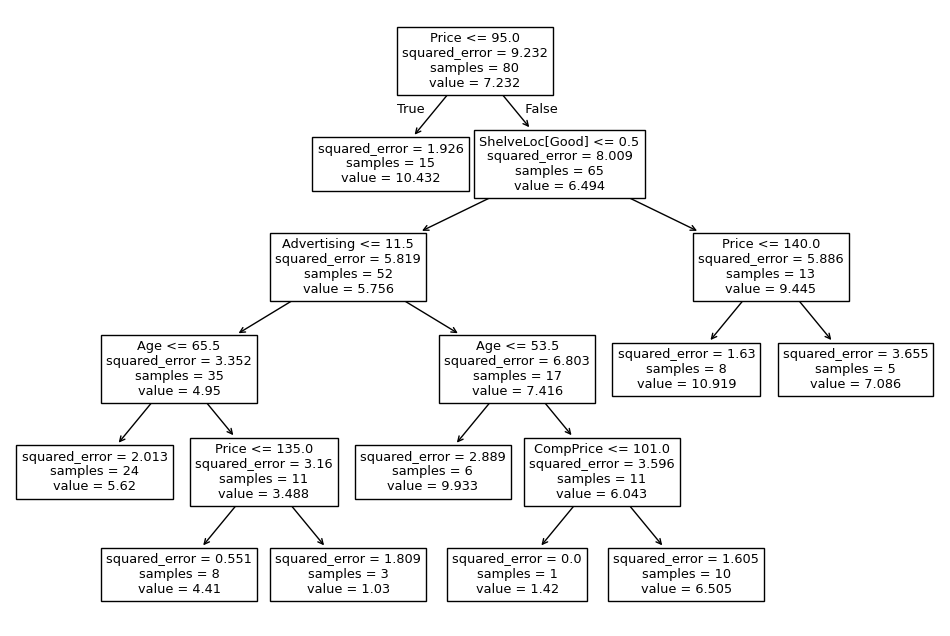

In [136]:
ccp = dtr.cost_complexity_pruning_path(X_treino,y_treino)

gs = GridSearchCV(dtr,
             {'ccp_alpha': ccp.ccp_alphas},
             refit=True,
             cv=10,
             scoring='neg_mean_squared_error')
gs.fit(X_treino, y_treino)
print(f'MSE Treino: {-gs.best_score_}\nMSE Teste: {np.mean((y_teste - gs.best_estimator_.predict(X_teste))**2)}')
ax = subplots(figsize=(12,8))[1]  
plot_tree(gs.best_estimator_,
          feature_names=nomes_preditores,
          ax=ax);


In [137]:
gs.best_estimator_.get_params()

{'ccp_alpha': np.float64(0.29383210227272627),
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

(d) Use the bagging approach in order to analyze this data. What
test MSE do you obtain? Use the feature_importance_ values to
determine which variables are most important.

In [138]:
bagging = RandomForestRegressor(max_features=X_teste.shape[1], random_state=42)
bagging.fit(X_treino, y_treino)
print(f'MSE Teste: {np.mean((y_teste - bagging.predict(X_teste))**2)}')
pd.DataFrame({'importancia':bagging.feature_importances_}, index=nomes_preditores).sort_values(by='importancia', ascending=False)

MSE Teste: 3.4579779041250007


,importancia
Price,0.379706
ShelveLoc[Good],0.162869
Age,0.125104
CompPrice,0.100567
Advertising,0.087116
Income,0.060357
Population,0.041400
Education,0.024768
Urban[Yes],0.008735
ShelveLoc[Medium],0.007517


(e) Use random forests to analyze this data. What test MSE do
you obtain? Use the feature_importance_ values to determine
which variables are most important. Describe the effect of m, the
number of variables considered at each split, on the error rate
obtained.

,importancia
Price,0.374009
ShelveLoc[Good],0.162158
Age,0.119898
CompPrice,0.103626
Advertising,0.090001
Income,0.059978
Population,0.045327
Education,0.025713
Urban[Yes],0.008926
ShelveLoc[Medium],0.007227


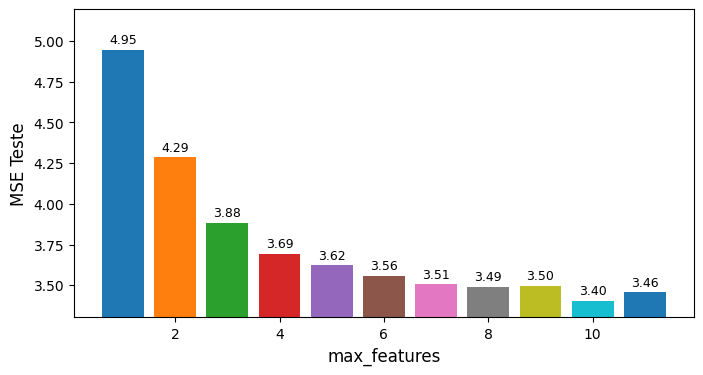

In [139]:
rf_melhor_modelo = None
melhor_mse_teste = np.inf
ax = subplots(figsize=(8,4))[1]
for i in range(1, X_teste.shape[1]+1):
    rf_ = RandomForestRegressor(max_features=i, random_state=42)
    rf_.fit(X_treino, y_treino)
    mse_ = np.mean((y_teste - rf_.predict(X_teste))**2)
    ax.bar(i, mse_)
    ax.text(i, mse_ + 0.02, f"{mse_:.2f}", ha='center', va='bottom', fontsize=9)
    if(mse_ < melhor_mse_teste):
        melhor_mse_teste = mse_
        rf_melhor_modelo = rf_
ax.set_ylim(bottom=melhor_mse_teste-0.1)
ax.set_ylabel('MSE Teste', fontsize=12)
ax.set_xlabel('max_features', fontsize=12)
pd.DataFrame({'importancia':rf_melhor_modelo.feature_importances_}, index=nomes_preditores).sort_values(by='importancia', ascending=False)

(f) Now analyze the data using BART, and report your results.

In [140]:
bart = BART(random_state=42)
bart.fit(X_treino, y_treino)
print(f'MSE Teste: {np.mean((y_teste - bart.predict(X_teste))**2)}')
pd.DataFrame({'importancia':bart.variable_inclusion_.mean(0)}, index=nomes_preditores).sort_values(by='importancia', ascending=False)

MSE Teste: 2.121407456959507


,importancia
Price,33.4
ShelveLoc[Good],30.1
CompPrice,28.4
Age,27.9
Advertising,27.2
US[Yes],27.2
Income,25.6
Education,25.4
ShelveLoc[Medium],24.8
Urban[Yes],24.3


# 9. # 
This problem involves the OJ data set which is part of the ISLP
package.

(a) Create a training set containing a random sample of 800 observations, and a test set containing the remaining observations.


In [231]:
OJ = load_data('OJ')
OJ.head(2)

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.0,0.0,0,0,0.5,1.99,1.75,0.24,No,0.000000,0.0,0.24,1
1,CH,239,1,1.75,1.99,0.0,0.3,0,1,0.6,1.69,1.75,-0.06,No,0.150754,0.0,0.24,1


In [232]:
OJ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Purchase        1070 non-null   category
 1   WeekofPurchase  1070 non-null   int64   
 2   StoreID         1070 non-null   int64   
 3   PriceCH         1070 non-null   float64 
 4   PriceMM         1070 non-null   float64 
 5   DiscCH          1070 non-null   float64 
 6   DiscMM          1070 non-null   float64 
 7   SpecialCH       1070 non-null   int64   
 8   SpecialMM       1070 non-null   int64   
 9   LoyalCH         1070 non-null   float64 
 10  SalePriceMM     1070 non-null   float64 
 11  SalePriceCH     1070 non-null   float64 
 12  PriceDiff       1070 non-null   float64 
 13  Store7          1070 non-null   category
 14  PctDiscMM       1070 non-null   float64 
 15  PctDiscCH       1070 non-null   float64 
 16  ListPriceDiff   1070 non-null   float64 
 17  STORE         

In [233]:
OJ[['Purchase', 'Store7']].value_counts()

Purchase  Store7
CH        No        379
MM        No        335
CH        Yes       274
MM        Yes        82
Name: count, dtype: int64

In [234]:
ms = ModelSpec(OJ.columns.drop('Purchase'))
D = ms.fit_transform(OJ)
nomes_preditores = D.columns
(X_treino,
 X_teste,
 y_treino,
 y_teste) = train_test_split(D, OJ.Purchase, train_size=800, random_state=0)

(b) Fit a tree to the training data, with Purchase as the response
and the other variables as predictors. What is the training error
rate?

In [235]:
dtc = DecisionTreeClassifier(random_state=0)
dtc.fit(X_treino, y_treino)
print(f'Treino Score: {dtc.score(X_treino, y_treino)}\nProfundidade: {dtc.get_depth()}')

Treino Score: 0.99125
Profundidade: 18


(c) Create a plot of the tree, and interpret the results. How many
terminal nodes does the tree have?

Quantidade de folhas: 166


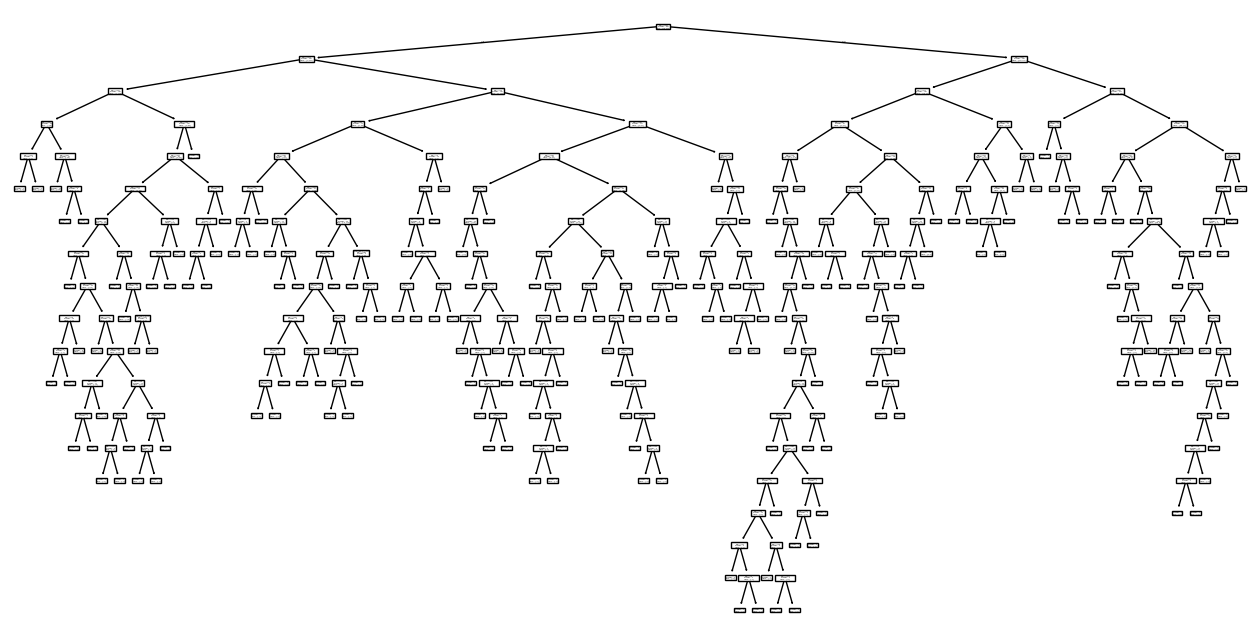

In [236]:
ax = subplots(figsize=(16,8))[1]
print(f'Quantidade de folhas: {dtc.get_n_leaves()}')
plot_tree(dtc,
          feature_names=nomes_preditores,
          ax=ax);

(d) Use the export_tree() function to produce a text summary of
the fitted tree. Pick one of the terminal nodes, and interpret the
information displayed.

In [237]:
print(export_text(dtc,
                  feature_names=nomes_preditores,
                  show_weights=True))

|--- LoyalCH <= 0.51
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- StoreID <= 1.50
|   |   |   |   |--- ListPriceDiff <= 0.15
|   |   |   |   |   |--- weights: [1.00, 0.00] class: CH
|   |   |   |   |--- ListPriceDiff >  0.15
|   |   |   |   |   |--- weights: [0.00, 2.00] class: MM
|   |   |   |--- StoreID >  1.50
|   |   |   |   |--- WeekofPurchase <= 268.50
|   |   |   |   |   |--- weights: [0.00, 49.00] class: MM
|   |   |   |   |--- WeekofPurchase >  268.50
|   |   |   |   |   |--- LoyalCH <= 0.00
|   |   |   |   |   |   |--- weights: [0.00, 7.00] class: MM
|   |   |   |   |   |--- LoyalCH >  0.00
|   |   |   |   |   |   |--- weights: [1.00, 0.00] class: CH
|   |   |--- LoyalCH >  0.06
|   |   |   |--- WeekofPurchase <= 273.50
|   |   |   |   |--- SalePriceCH <= 1.94
|   |   |   |   |   |--- WeekofPurchase <= 263.50
|   |   |   |   |   |   |--- STORE <= 1.50
|   |   |   |   |   |   |   |--- WeekofPurchase <= 228.00
|   |   |   |   |   |   |   |   |--- weigh

(e) Predict the response on the test data, and produce a confusion
matrix comparing the test labels to the predicted test labels.
What is the test error rate?

In [238]:
dtc_predicao = dtc.predict(X_teste)
print('Acurácia Teste:',accuracy_score(y_teste, dtc_predicao))
print('Taxa de Erro:',1-accuracy_score(y_teste, dtc_predicao))
confusion_table(dtc_predicao, y_teste)

Acurácia Teste: 0.7555555555555555
Taxa de Erro: 0.24444444444444446


Truth,CH,MM
Predicted,,
CH,117,30
MM,36,87


(f) Use cross-validation on the training set in order to determine
the optimal tree size.

In [239]:
ccp = dtc.cost_complexity_pruning_path(X_treino, y_treino)

gs = GridSearchCV(dtc,
                  {'max_depth': range(1,21)},
                  refit=True,
                  scoring='accuracy',
                  cv=10)
gs.fit(X_treino, y_treino)
print(f'Acurácia Treino CV: {gs.best_score_}\nProfundidade:{gs.best_estimator_.get_depth()}')

Acurácia Treino CV: 0.80375
Profundidade:5


(g) Produce a plot with tree size on the x-axis and cross-validated
classification error rate on the y-axis.

(h) Which tree size corresponds to the lowest cross-validated classification error rate?

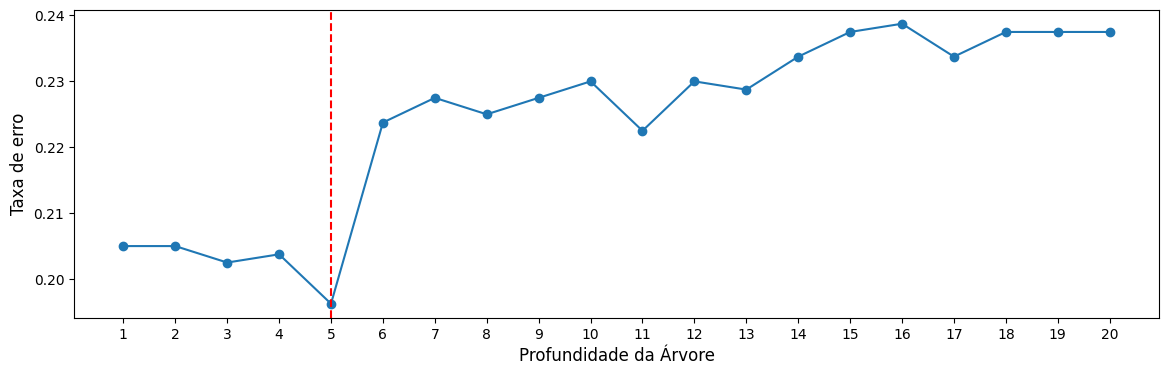

In [240]:
ax = subplots(figsize=(14,4))[1]

ax.plot(gs.cv_results_['param_max_depth'].data, 1- gs.cv_results_['mean_test_score'], '-o')
ax.axvline(gs.best_estimator_.get_depth(), c='r', ls='--')
ax.set_ylabel('Taxa de erro', fontsize=12)
ax.set_xlabel('Profundidade da Árvore', fontsize=12)
ax.set_xticks(gs.cv_results_['param_max_depth'].data);

(i) Produce a pruned tree corresponding to the optimal tree size
obtained using cross-validation. If cross-validation does not lead
to selection of a pruned tree, then create a pruned tree with five
terminal nodes.

(j) Compare the training error rates between the pruned and un
pruned trees. Which is higher?

(k) Compare the test error rates between the pruned and unpruned
trees. Which is higher?

In [241]:
gs_p = GridSearchCV(DecisionTreeClassifier(random_state=0),
                    {'ccp_alpha': gs.best_estimator_.cost_complexity_pruning_path(X_treino, y_treino).ccp_alphas},
                    cv=10,
                    scoring='accuracy')
gs_p.fit(X_treino, y_treino)
print(f'Acurácia Treino CV: {gs_p.best_score_}\nProfundidade:{gs_p.best_estimator_.get_depth()}')

Acurácia Treino CV: 0.8025
Profundidade:3


Text(0.5, 0, 'Árvore')

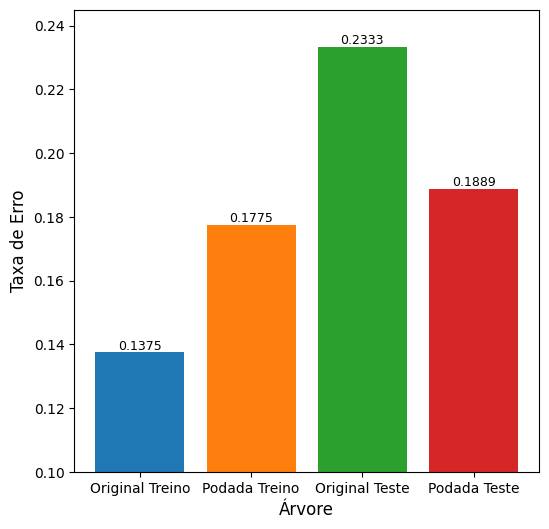

In [244]:
original_acc_treino = 1-gs.best_estimator_.score(X_treino, y_treino)
original_acc_teste = 1-gs.best_estimator_.score(X_teste, y_teste)
podada_acc_treino = 1-gs_p.best_estimator_.score(X_treino, y_treino)
podada_acc_teste = 1-gs_p.best_estimator_.score(X_teste, y_teste)

ax = subplots(figsize=(6,6))[1]
ax.bar('Original Treino', original_acc_treino)
ax.text('Original Treino', original_acc_treino, f'{original_acc_treino:.4f}', ha='center', va='bottom', fontsize=9)
ax.bar('Podada Treino', podada_acc_treino)
ax.text('Podada Treino', podada_acc_treino, f'{podada_acc_treino:.4f}', ha='center', va='bottom', fontsize=9)
ax.bar('Original Teste', original_acc_teste)
ax.text('Original Teste', original_acc_teste, f'{original_acc_teste:.4f}', ha='center', va='bottom', fontsize=9)
ax.bar('Podada Teste', podada_acc_teste)
ax.text('Podada Teste', podada_acc_teste, f'{podada_acc_teste:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(bottom=0.1)

ax.set_ylabel('Taxa de Erro', fontsize=12)
ax.set_xlabel('Árvore', fontsize=12)

In [243]:
confusion_table(y_teste, gs_p.best_estimator_.predict(X_teste))

Truth,CH,MM
Predicted,,
CH,138,15
MM,36,81


# 10. # 
We now use boosting to predict Salary in the Hitters data set.

(a) Remove the observations for whom the salary information is
unknown, and then log-transform the salaries.

(b) Create a training set consisting of the first 200 observations, and
a test set consisting of the remaining observations.

In [2]:
Hitters = load_data('Hitters').dropna()
Hitters.Salary = np.log(Hitters.Salary)
Hitters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      263 non-null    int64   
 1   Hits       263 non-null    int64   
 2   HmRun      263 non-null    int64   
 3   Runs       263 non-null    int64   
 4   RBI        263 non-null    int64   
 5   Walks      263 non-null    int64   
 6   Years      263 non-null    int64   
 7   CAtBat     263 non-null    int64   
 8   CHits      263 non-null    int64   
 9   CHmRun     263 non-null    int64   
 10  CRuns      263 non-null    int64   
 11  CRBI       263 non-null    int64   
 12  CWalks     263 non-null    int64   
 13  League     263 non-null    category
 14  Division   263 non-null    category
 15  PutOuts    263 non-null    int64   
 16  Assists    263 non-null    int64   
 17  Errors     263 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  263 non-null    categor

In [174]:
ms = ModelSpec(Hitters.columns.drop('Salary'))
D = ms.fit_transform(Hitters)
nomes_preditores = D.columns
(X_treino_lin,
 X_teste_lin,
 y_treino,
 y_teste) = train_test_split(D, 
                             Hitters.Salary,
                             train_size=200,
                             random_state=12)
X_treino = X_treino_lin.drop(columns=['intercept'])
X_teste = X_teste_lin.drop(columns=['intercept'])


(c) Perform boosting on the training set with 1,000 trees for a range
of values of the shrinkage parameter λ. Produce a plot with
different shrinkage values on the x-axis and the corresponding
training set MSE on the y-axis.

(d) Produce a plot with different shrinkage values on the x-axis and
the corresponding test set MSE on the y-axis.

In [175]:
qtd_modelos = 50
taxas_aprendizagem = np.linspace(1e-4 , 2e-1, num=qtd_modelos)

melhor_modelo_gb = None
melhor_mse_teste = np.inf
melhor_taxa_teste = np.inf
mses_treino = []
mses_teste = []
for taxa_aprendizagem in taxas_aprendizagem:
    gd_b_r = GradientBoostingRegressor(n_estimators=1000, max_depth=2, learning_rate=taxa_aprendizagem, random_state=0)
    gd_b_r.fit(X_treino, y_treino)
    mse_treino = np.mean((y_treino - gd_b_r.predict(X_treino))**2)
    mses_treino.append(mse_treino)

    mse_teste = np.mean((y_teste - gd_b_r.predict(X_teste))**2)
    mses_teste.append(mse_teste)

    if(mse_teste < melhor_mse_teste):
        melhor_mse_teste = mse_teste
        melhor_modelo_gb = gd_b_r
        melhor_taxa_teste = taxa_aprendizagem

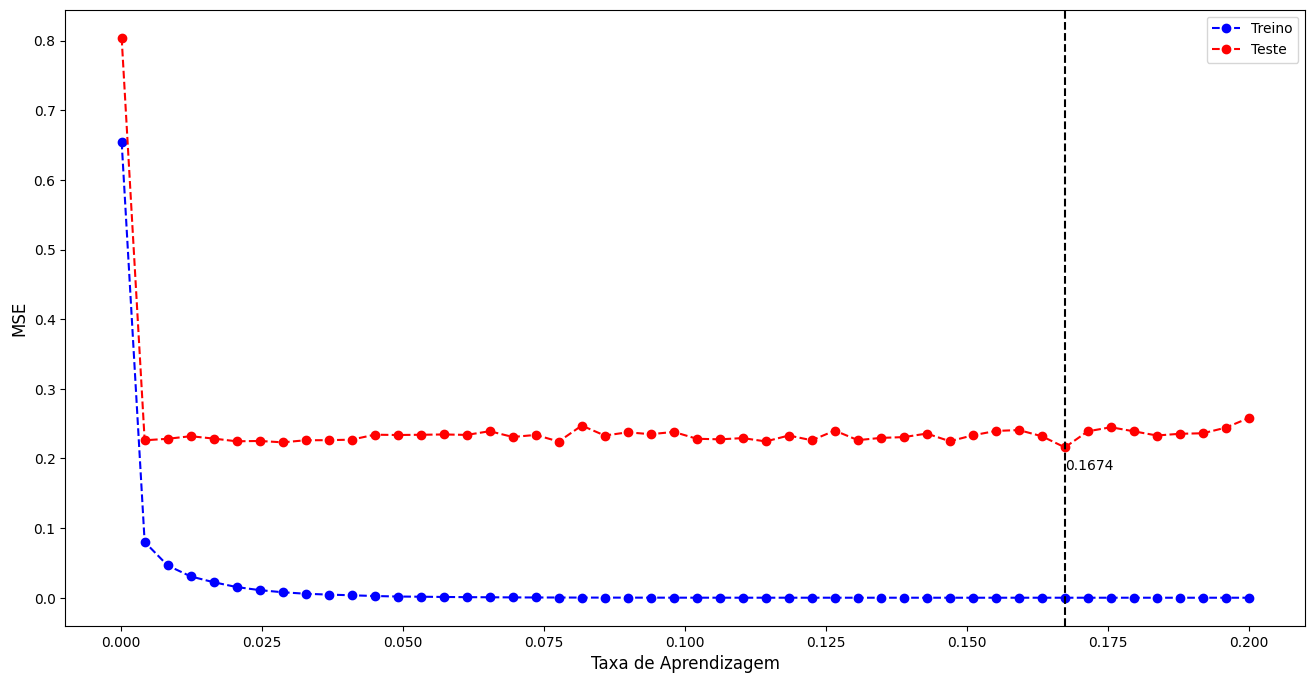

In [176]:
ax = subplots(figsize=(16,8))[1]
ax.plot(taxas_aprendizagem, mses_treino, 'o--b', label='Treino')
ax.plot(taxas_aprendizagem, mses_teste, 'o--r', label='Teste')
ax.text(melhor_taxa_teste, min(mses_teste) - min(mses_teste)*0.15, f'{ melhor_taxa_teste:.4f}')
ax.axvline(melhor_taxa_teste, ls='--', c='k')
ax.set_xlabel('Taxa de Aprendizagem', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.legend();

(e) Compare the test MSE of boosting to the test MSE that results
from applying two of the regression approaches seen in
Chapters 3 and 6.

In [ ]:
lasso = LassoCV(alphas=200, cv=10, max_iter=2000)
lasso.fit(X_treino_lin, y_treino)
lasso_mse_teste = np.mean((y_teste - lasso.predict(X_teste_lin))**2)

ridge = RidgeCV(alphas=np.linspace(1e-4, 1e2, 200), cv=10)
ridge.fit(X_treino_lin, y_treino)
ridge_mse_teste = np.mean((y_teste - ridge.predict(X_teste_lin))**2)


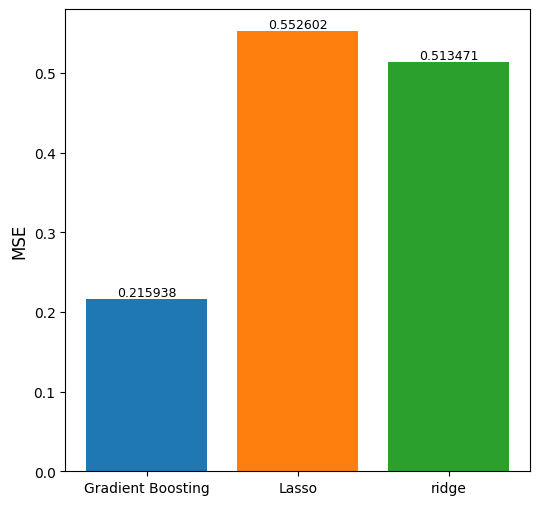

In [185]:
ax = subplots(figsize=(6,6))[1]
ax.bar('Gradient Boosting',melhor_mse_teste)
ax.text('Gradient Boosting',melhor_mse_teste, f'{melhor_mse_teste:4f}', ha='center', va='bottom', fontsize=9)
ax.bar('Lasso',lasso_mse_teste)
ax.text('Lasso',lasso_mse_teste, f'{lasso_mse_teste:4f}', ha='center', va='bottom', fontsize=9)
ax.bar('ridge',ridge_mse_teste)
ax.text('ridge',ridge_mse_teste, f'{ridge_mse_teste:4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('MSE', fontsize=12);

(f) Which variables appear to be the most important predictors in
the boosted model?

In [187]:
pd.DataFrame({'preditor':melhor_modelo_gb.feature_importances_}, index=nomes_preditores.drop('intercept')).sort_values(by='preditor',ascending=False)

,preditor
CAtBat,0.395676
CWalks,0.099713
CHits,0.099126
CRBI,0.073387
AtBat,0.066439
Years,0.064403
Hits,0.040685
CRuns,0.034729
Walks,0.031172
CHmRun,0.027717


(g) Now apply bagging to the training set. What is the test set MSE
for this approach

In [199]:
n_estimadores = range(100, 2_000, 100)
melhor_modelo_rf = None
melhor_mse_teste = np.inf
melhor_n_est = np.inf

mses_treino = []
mses_teste = []

for n_e in n_estimadores:
    rf = RandomForestRegressor(max_features=len(X_treino.columns), n_estimators=n_e, random_state=0)
    rf.fit(X_treino, y_treino)
    
    mses_treino.append(np.mean((y_treino - rf.predict(X_treino))**2))
    mse_teste = np.mean((y_teste - rf.predict(X_teste))**2)
    mses_teste.append(mse_teste)

    if(mse_teste < melhor_mse_teste):
        melhor_mse_teste = mse_teste
        melhor_modelo_rf = rf
        melhor_n_est = n_e

print(f'MSE Teste: {melhor_mse_teste}')

MSE Teste: 0.21157915860421886


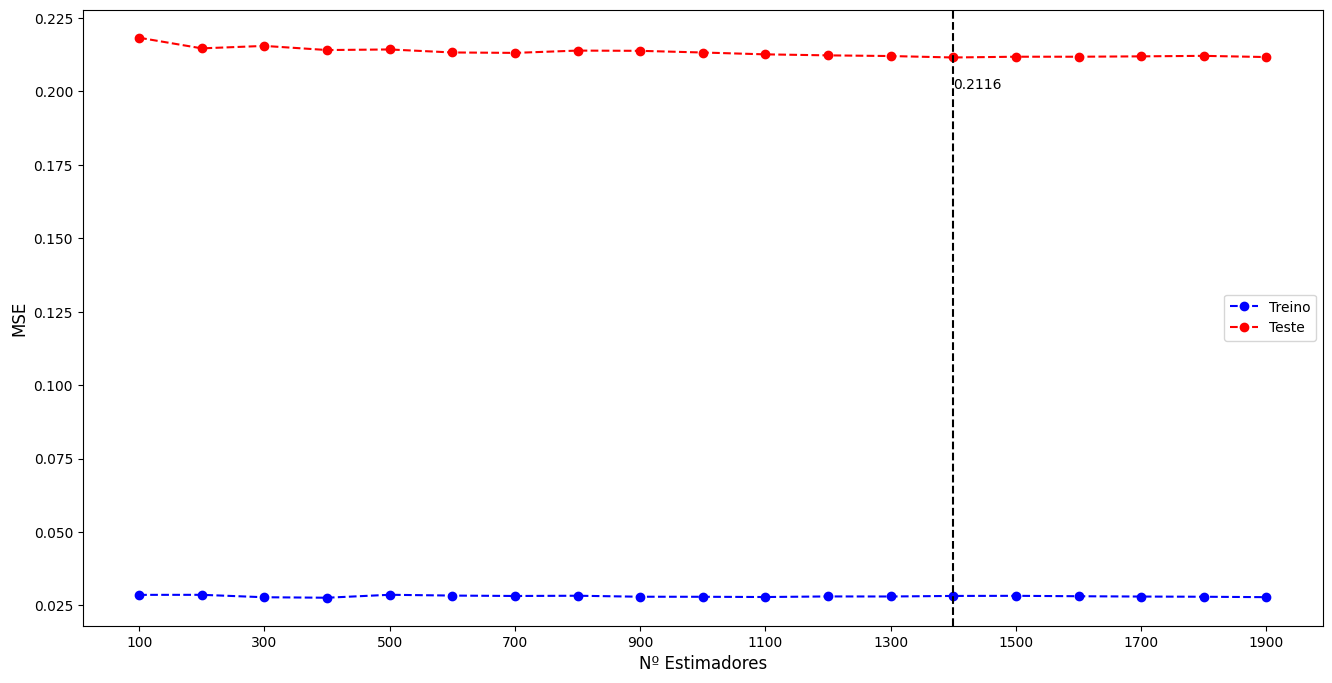

In [207]:
ax = subplots(figsize=(16,8))[1]
ax.plot(n_estimadores, mses_treino, 'o--b', label='Treino')
ax.plot(n_estimadores, mses_teste, 'o--r', label='Teste')
ax.text(melhor_n_est, melhor_mse_teste - melhor_mse_teste*0.05, f'{ melhor_mse_teste:.4f}')
ax.axvline(melhor_n_est, ls='--', c='k')
ax.set_xlabel('Nº Estimadores', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_xticks(n_estimadores[::2])
ax.legend();

# 11. #

This question uses the Caravan data set.

(a) Create a training set consisting of the first 1,000 observations,
and a test set consisting of the remaining observations.

In [127]:
Caravan = load_data('Caravan')
D = ModelSpec(Caravan.columns.drop('Purchase'), intercept=False).fit_transform(Caravan)
nomes_preditores = D.columns
X = np.asarray(D)
y = Caravan['Purchase']

(X_treino, X_teste, y_treino, y_teste) = X[:1000], X[1000:], y[:1000], y[1000:]

(b) Fit a boosting model to the training set with Purchase as the
response and the other variables as predictors. Use 1,000 trees,
and a shrinkage value of 0.01. Which predictors appear to be
the most important?

In [128]:
gd_b_c = GradientBoostingClassifier(n_estimators=1_000, learning_rate=0.01, max_depth=5, random_state=0)
gd_b_c.fit(X_treino, y_treino)
print('Acurácia treino:', gd_b_c.score(X_treino, y_treino))
pd.DataFrame({'importancia': gd_b_c.feature_importances_}, index=nomes_preditores).sort_values(by='importancia', ascending=False).head(3)

Acurácia treino: 0.996


,importancia
PPERSAUT,0.059846
MOSTYPE,0.058628
MGODGE,0.049597


(c) Use the boosting model to predict the response on the test data.
Predict that a person will make a purchase if the estimated probability of purchase is greater than 20%. Form a confusion matrix. What fraction of the people predicted to make a purchase do in fact make one?

How does this compare with the results
obtained from applying KNN or logistic regression to this data
set?

In [129]:
y_teste_proba = gd_b_c.predict_proba(X_teste)[:,1]
y_teste_pred = np.where(y_teste_proba > 0.2, 'Yes', 'No')
print('Acurácia:', accuracy_score(y_teste, y_teste_pred))
print('Precisão:', precision_score(y_teste, y_teste_pred, pos_label='Yes'))
print('Sensibilidade:', recall_score(y_teste, y_teste_pred, pos_label='Yes'))
print('f1_score:', f1_score(y_teste, y_teste_pred, pos_label='Yes'))
confusion_table(y_teste_pred, y_teste)

Acurácia: 0.9114475321443385
Precisão: 0.14795918367346939
Sensibilidade: 0.10034602076124567
f1_score: 0.11958762886597939


Truth,No,Yes
Predicted,,
No,4366,260
Yes,167,29


In [130]:
lr = LogisticRegression(max_iter=1_000, random_state=0).fit(X_treino, y_treino)
y_teste_proba = lr.predict_proba(X_teste)[:,1]
y_teste_pred = np.where(y_teste_proba > 0.2, 'Yes', 'No')
print('Acurácia:', accuracy_score(y_teste, y_teste_pred))
print('Precisão:', precision_score(y_teste, y_teste_pred, pos_label='Yes'))
print('Sensibilidade:', recall_score(y_teste, y_teste_pred, pos_label='Yes'))
print('f1_score:', f1_score(y_teste, y_teste_pred, pos_label='Yes'))
confusion_table(y_teste_pred, y_teste)

Acurácia: 0.9014931563666528
Precisão: 0.17708333333333334
Sensibilidade: 0.17647058823529413
f1_score: 0.17677642980935876


Truth,No,Yes
Predicted,,
No,4296,238
Yes,237,51


In [131]:
knn = KNeighborsClassifier(n_neighbors=1).fit(X_treino, y_treino)
y_teste_proba = knn.predict_proba(X_teste)[:,1]
y_teste_pred = np.where(y_teste_proba > 0.2, 'Yes', 'No')
print('Acurácia:', accuracy_score(y_teste, y_teste_pred))
print('Precisão:', precision_score(y_teste, y_teste_pred, pos_label='Yes'))
print('Sensibilidade:', recall_score(y_teste, y_teste_pred, pos_label='Yes'))
print('f1_score:', f1_score(y_teste, y_teste_pred, pos_label='Yes'))
confusion_table(y_teste_pred, y_teste)

Acurácia: 0.8886354209871422
Precisão: 0.0782312925170068
Sensibilidade: 0.07958477508650519
f1_score: 0.07890222984562607


Truth,No,Yes
Predicted,,
No,4262,266
Yes,271,23


# 12. # 
Apply boosting, bagging, random forests, and BART to a data set
of your choice. Be sure to fit the models on a training set and to
evaluate their performance on a test set. How accurate are the results
compared to simple methods like linear or logistic regression? Which
of these approaches yields the best performance?


In [333]:
Caravan = load_data('Caravan')
D = ModelSpec(Caravan.columns.drop('Purchase'), intercept=False).fit_transform(Caravan)
nomes_preditores = D.columns
X = np.asarray(D)
y = Caravan['Purchase']

(X_treino, X_teste, y_treino, y_teste) = train_test_split(X, y, random_state=0, test_size=0.2, stratify=y)

In [334]:
melhor_modelo_bagging = None
qtd_estimadores = range(100, 500, 50)
sensibilidades = []
f1s = []
melhor_f1 = -np.inf
melhor_qtd_estimadores = -np.inf

for n_estimadores in qtd_estimadores:
    rfc = RandomForestClassifier(n_estimators=n_estimadores, max_features=X_treino.shape[1], random_state=0).fit(X_treino, y_treino)
    y_teste_pred = rfc.predict(X_teste)
    sensibilidades.append(recall_score(y_teste, y_teste_pred, pos_label='Yes'))
    f1_ = f1_score(y_teste, y_teste_pred, pos_label='Yes')
    f1s.append(f1_)
    if f1_ > melhor_f1:
        melhor_f1 = f1_
        melhor_qtd_estimadores = n_estimadores
        melhor_modelo_bagging = rfc


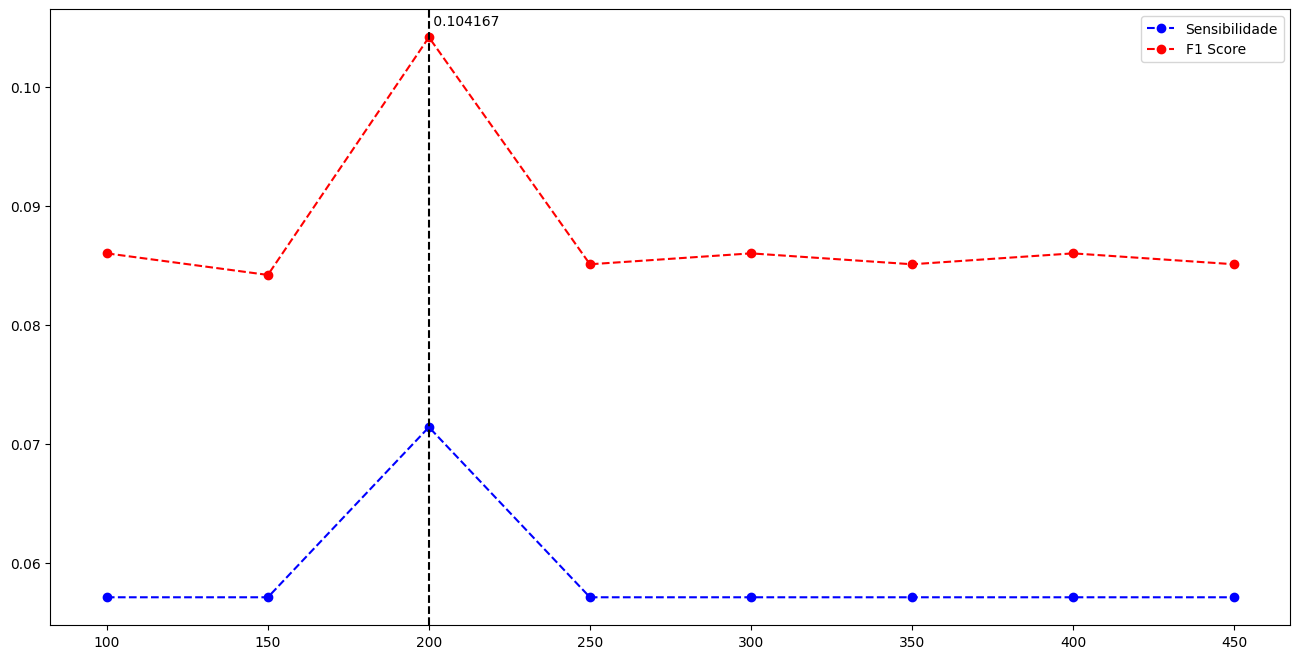

In [335]:
ax = subplots(figsize=(16,8))[1]
ax.plot(qtd_estimadores, sensibilidades, 'o--b', label='Sensibilidade')
ax.plot(qtd_estimadores, f1s, 'o--r', label='F1 Score')
ax.axvline(melhor_qtd_estimadores, ls='--', c='k')
ax.text(melhor_qtd_estimadores, melhor_f1+(melhor_f1*0.01), f' {melhor_f1:4f}')
ax.set_xticks(qtd_estimadores)
ax.legend();

In [365]:
melhor_modelo_forest = None
qtds_max_features = range(1, X_treino.shape[1], 5)
sensibilidades = []
f1s = []
melhor_f1 = -np.inf
melhor_qtd_max_features = -np.inf

for max_features in qtds_max_features:
    rfc = RandomForestClassifier(n_estimators=500, max_features=max_features, random_state=0).fit(X_treino, y_treino)
    y_teste_pred = rfc.predict(X_teste)
    sensibilidades.append(recall_score(y_teste, y_teste_pred, pos_label='Yes'))
    f1_ = f1_score(y_teste, y_teste_pred, pos_label='Yes')
    f1s.append(f1_)
    if f1_ > melhor_f1:
        melhor_f1 = f1_
        melhor_qtd_max_features = max_features
        melhor_modelo_forest = rfc

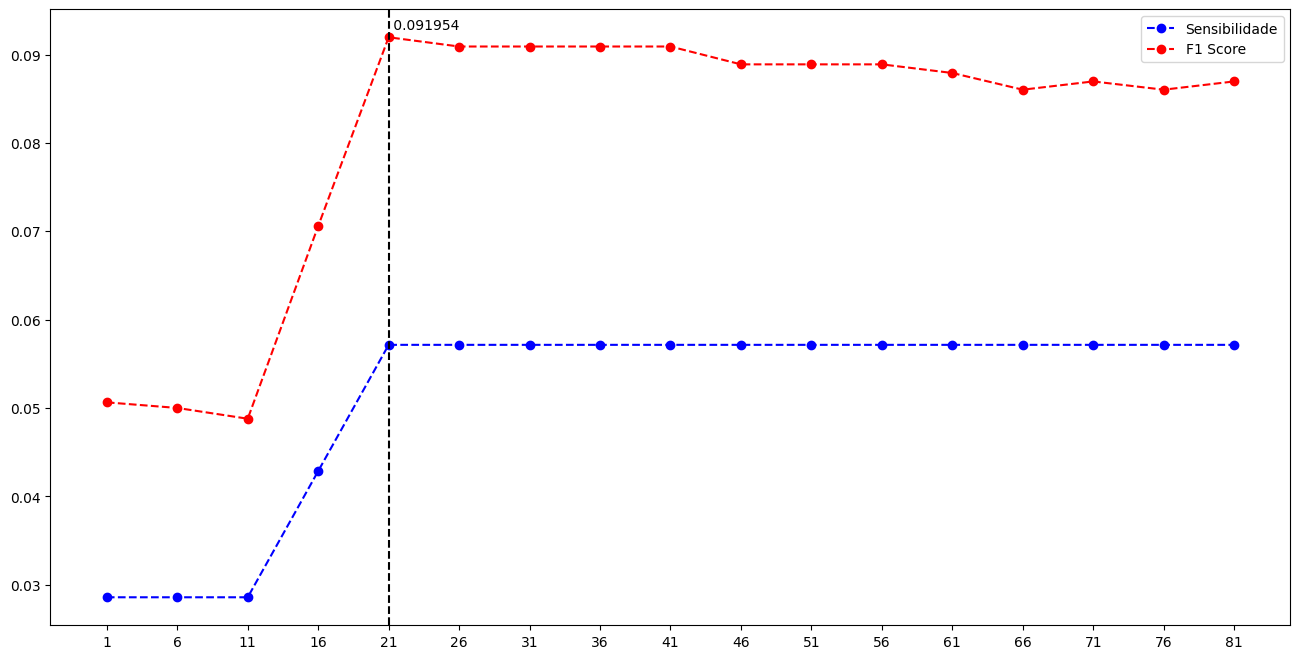

In [366]:
ax = subplots(figsize=(16,8))[1]
ax.plot(qtds_max_features, sensibilidades, 'o--b', label='Sensibilidade')
ax.plot(qtds_max_features, f1s, 'o--r', label='F1 Score')
ax.axvline(melhor_qtd_max_features, ls='--', c='k')
ax.text(melhor_qtd_max_features, melhor_f1+(melhor_f1*0.01), f' {melhor_f1:4f}')
ax.set_xticks(qtds_max_features)
ax.legend();

In [361]:
melhor_modelo_boosting = None
taxas_aprendizagem = np.linspace(1e-1, 7, 80)
sensibilidades = []
f1s = []
melhor_f1 = -np.inf
melhor_taxa_aprendizagem = -np.inf

for taxa_aprendizagem in taxas_aprendizagem:
    gd_b_c = GradientBoostingClassifier(n_estimators=200, learning_rate=taxa_aprendizagem, random_state=0, max_features=21)
    gd_b_c.fit(X_treino, y_treino)
    y_teste_pred = gd_b_c.predict(X_teste)
    sensibilidades.append(recall_score(y_teste, y_teste_pred, pos_label='Yes'))
    f1_ = f1_score(y_teste, y_teste_pred, pos_label='Yes')
    f1s.append(f1_)
    if f1_ > melhor_f1:
        melhor_f1 = f1_
        melhor_taxa_aprendizagem = taxa_aprendizagem
        melhor_modelo_boosting = gd_b_c



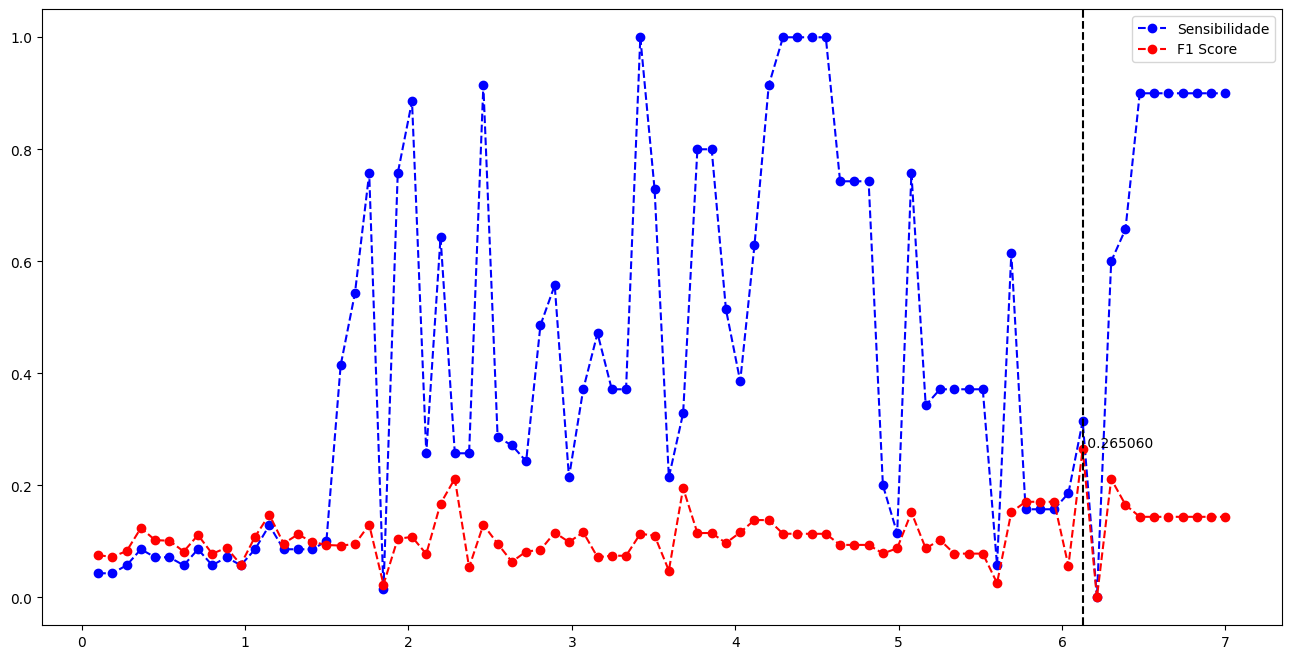

In [363]:
ax = subplots(figsize=(16,8))[1]
ax.plot(taxas_aprendizagem, sensibilidades, 'o--b', label='Sensibilidade')
ax.plot(taxas_aprendizagem, f1s, 'o--r', label='F1 Score')
ax.axvline(melhor_taxa_aprendizagem, ls='--', c='k')
ax.text(melhor_taxa_aprendizagem, melhor_f1+(melhor_f1*0.01), f' {melhor_f1:4f}')
ax.legend();

In [364]:
y_teste_pred = melhor_modelo_boosting.predict(X_teste)
print('Acurácia:', accuracy_score(y_teste, y_teste_pred))
print('Precisão:', precision_score(y_teste, y_teste_pred, pos_label='Yes'))
print('Sensibilidade:', recall_score(y_teste, y_teste_pred, pos_label='Yes'))
print('f1_score:', f1_score(y_teste, y_teste_pred, pos_label='Yes'))
confusion_table(y_teste_pred, y_teste)

Acurácia: 0.8952789699570816
Precisão: 0.22916666666666666
Sensibilidade: 0.3142857142857143
f1_score: 0.26506024096385544


Truth,No,Yes
Predicted,,
No,1021,48
Yes,74,22
